# EXERCISE 07: Montecarlo simulation of LJ system

## 07.1
**In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.**

I implemented the tail corrections in the *initialize_properties()* function:

**potential energy correction:**
```c++
        _vtail = A/double(9*pow(_r_cut,9))-A/double(3*pow(_r_cut,3)); 
        

**pressure correction**
```c++
        _ptail = (32.*M_PI*_rho)*(1./double(9*pow(_r_cut,9))-1./double(6*pow(_r_cut,3))); 
       

The values I obtained are:
- vtail = -0.428346
- ptail = 

SCRIVERE VALORI DI VTAIL E PTAIL(DEVONO VENIRE CIRCA 0.5), CORREGGERE EX4 TOGLIENDO TAIL CORRECTION

## 07.2
### Exercise 07.2

<b>Use the NSL simulator code to <span style="color:red">print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations</span> of $M=5\times 10^5$ MC steps or MD time steps in the following thermodynamic conditions:<b>
- **liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)**
1. <b>Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. <b>Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. <span style="color:red">Make pictures of these statistical uncertainties as a function of $L$.</span> What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

### Preliminary analysis
#### MC ACCEPTANCE
In order to obtain correct results with the MC method, my first step was to determine the optimal step_length to obtain an acceotance of 50%. To do so I performed 10 simple simulations in which I let the system evolve for 5000 steps and determined the acceptance rate.

#### EQUILIBRATION 
To equilibrate the system, I tried different starting temperatures and let the system evolve for 3000 steps. I determined that stOptimal starting temperature is 1.97,since the temperature becomes well stabilized around the desired value. From the following plot I also deduced that 1500 steps are sufficient to reach stability.

Therefore I chose dt=0.16

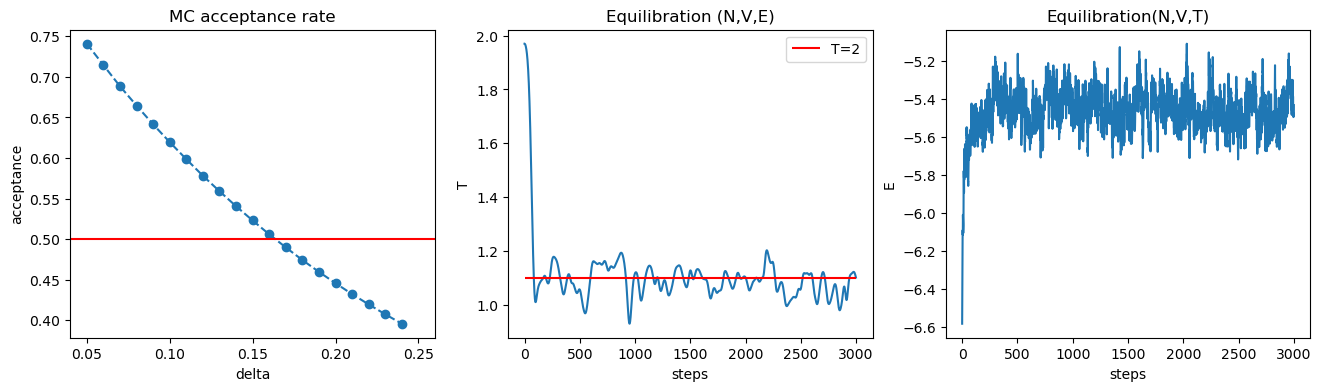

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
file= "./OUTPUT/Equilibration_MD.csv"
df1 = pd.read_csv(file,sep ="\t")
file= "./OUTPUT/Equilibration_MC.csv"
df2 = pd.read_csv(file,sep ="\t")
Neq_steps=len(df1['Step'])

file= "./OUTPUT/acceptance_tries.csv"
df =pd.read_csv(file,sep ='\t')

fig,ax = plt.subplots(1,3,figsize=(16,4))
ax[0].plot(df['DELTA'],df['ACCEPTANCE'],marker ='o', linestyle='dashed')
ax[0].hlines(0.5,0.04,0.26, color= 'red')
ax[0].set_xlabel('delta')
ax[0].set_ylabel('acceptance')
ax[0].set_xlim(0.04,0.26)
ax[0].set_title('MC acceptance rate')
ax[1].plot(df1['Step'],df1['Temp'])
ax[1].hlines(1.1,0,Neq_steps,color='r',label = 'T=2')
ax[1].set_xlabel('steps')
ax[1].set_ylabel('T')
ax[1].legend()
ax[1].set_title(f'Equilibration (N,V,E)')

ax[2].plot(df2['Step'],df2['Energy'])
ax[2].set_xlabel('steps')
ax[2].set_ylabel('E')
ax[2].set_title(f'Equilibration(N,V,T)')

plt.show()

#### U/N AUTOCORRELATION

After the 1500 equilibration steps in which I don't make any measurements, I performed 500000 steps of MD and MC to obtain the instant values of $\frac{U}{N}$

The autocorrelation function for a finite set of MC time steps can be computed as :
$$\chi(t) = \frac{\frac{\sum_{t'=0}^{t_{max}-t}f(t')f(t'+t)}{t_{max}-t}-\frac{\Big(\sum_{t'=0}^{t_{max}-t}f(t')\Big)\Big(\sum_{t'=0}^{t_{max}-t}f(t'+t)\Big)}{(t_{max}-t)^2}}{\frac{\sum_{t'=0}^{t_{max}}f^2(t')}{t_{max}}-\Big(\frac{\sum_{t'=0}^{t_{max}}f(t')}{t_{max}}\Big)^2} = \frac{\langle f(t'<t)f(t<t'<t_{max})\rangle -\langle f(t'<t)\rangle \langle f(t<t'<t_{max})\rangle}{\langle f^2(t')\rangle -(\langle f(t') \rangle )^2}$$ 

In [10]:
import numpy as np

def autocorrelation (data, t:int,tmax:int):
    sum1 = np.sum(data[:(tmax-t)]*data[t:tmax])
    sum2 = np.sum(data[:tmax-t])
    sum3= np.sum(data[t:tmax])
    var = (np.sum(data**2)/(tmax))-((np.sum(data)/(tmax))**2)
    #var = np.mean(data**2)-(np.mean(data))**2
    chi=(sum1/(tmax-t)-(sum2*sum3)/((tmax-t)**2))/var

    if (np.isnan(chi)): return 0
    else :return chi
    #return (sum1-sum2*sum3)/var


def model(x,tc): 
    return np.exp(-x/tc)

I computed the autocorrelationfor both (N,V,E) and (N,V,T) simulation for 1000 time values evenly spaced in the time interval (0,500000). 

In [11]:
import pandas as pd
fileMD= ("./OUTPUT/potential_energy_MD_instant.csv")
df = pd.read_csv(fileMD,sep = '\t')
df.head()

Ndata = len(df)
len_t = 100
nt = int(Ndata/len_t)
print(f'Data points: {Ndata}, Autocorrelation commputed for {nt} time values (intervals of {len_t} points)')

data = np.array(df['ACTUAL_PE'])
times = np.linspace (0,500000,nt+1,dtype=int)
#times = np.array(df['BLOCK'][::1000])
tmax = times[-1]
print(tmax)
chiMD =np.zeros(len(times))
for i,t in enumerate(times):
    chiMD[i] = autocorrelation(data,t,tmax)
#print(chiMD[990:])

Data points: 500000, Autocorrelation commputed for 5000 time values (intervals of 100 points)
500000


/tmp/ipykernel_99544/1957812413.py:9: RuntimeWarning: invalid value encountered in scalar divide
  chi=(sum1/(tmax-t)-(sum2*sum3)/((tmax-t)**2))/var


In [9]:
import pandas as pd
fileMC= ("./OUTPUT/potential_energy_MC_instant.csv")
df1 = pd.read_csv(fileMC,sep = '\t')
df1.head()
dataMC = np.array(df1['ACTUAL_PE'])
times = np.linspace (0,500000,nt+1,dtype=int)
#times = np.array(df1['BLOCK'][::1000])
tmax=times[-1]
print(len(times))
chiMC =np.zeros(len(times))
for i,t in enumerate(times):
    chiMC[i] = autocorrelation(dataMC,t,tmax)

5001


/tmp/ipykernel_4466/1957812413.py:9: RuntimeWarning: invalid value encountered in scalar divide
  chi=(sum1/(tmax-t)-(sum2*sum3)/((tmax-t)**2))/var


In [10]:
from scipy.optimize import curve_fit
reduced_t = times/len_t
tc,tc_err = curve_fit(model,reduced_t,chiMD)
print(f'correlation time fit(NVE):{tc}')
print(f'correlation time error(NVE):{tc_err}')

tc1,tc_err1 = curve_fit(model,reduced_t,chiMC)
print(f'correlation time fit(NVT):{tc1}')
print(f'correlation time error(NVT):{tc_err1}')

correlation time fit(NVE):[0.26663242]
correlation time error(NVE):[[0.0102327]]
correlation time fit(NVT):[0.26913239]
correlation time error(NVT):[[0.00107301]]


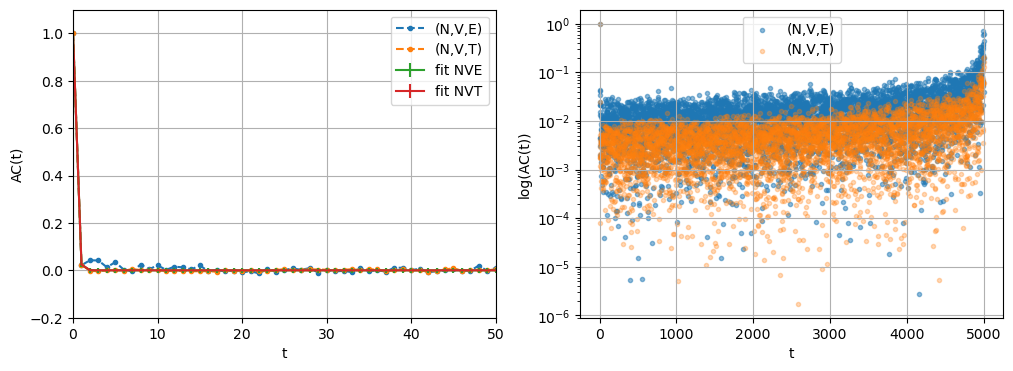

In [16]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(reduced_t,chiMD,label ='(N,V,E)',marker='.',linestyle='dashed')
ax[0].plot(reduced_t,chiMC,label ='(N,V,T)',marker='.',linestyle='dashed')
ax[0].errorbar(reduced_t,model(reduced_t,tc),yerr=tc_err,label='fit NVE')
ax[0].errorbar(reduced_t,model(reduced_t,tc1),yerr=tc_err1,label='fit NVT')
ax[0].legend()
ax[0].grid()
ax[0].set_xlim(0,50)
ax[0].set_ylim(-0.2,1.1)
ax[0].set_xlabel('t')
ax[0].set_ylabel('AC(t)')

ax[1].scatter(reduced_t,abs(chiMD),marker='.',alpha=0.5,label ='(N,V,E)')
ax[1].scatter(reduced_t,abs(chiMC),marker='.',alpha =0.3,label='(N,V,T)')
#ax[1].plot(times/500,abs(model(times/500,tc)),label='fit')
#ax[1].plot(times/500,model(times/500,tc1),label='fit NVT')
ax[1].set_yscale('log')
#ax[1].set_xlim(0,20)
ax[1].set_xlabel('t')
ax[1].set_ylabel('log(AC(t))')


ax[1].legend()
ax[1].grid()


#ax[0].plot(times/500,fit)

#### U/N BLOCK LENGTH

In [35]:
M = 500000
L=np.linspace(10,5000,100,dtype=int)
blocks = np.array(df['BLOCKS'])
mean_ave= np.zeros()
for bl_length in L:
    mask = blocks[bl:L[i+1]]
    

[5000.          827.81456954  451.26353791  310.17369727  236.29489603
  190.83969466  160.05121639  137.81697905  121.00677638  107.8515962
   97.27626459   88.58965273   81.3272609    75.1653638    69.87143656
   65.27415144   61.244488     57.68343332   54.51373746   51.67424556
   49.11591356   46.7989517    44.69074008   42.76428327   40.99704821
   39.36697898   37.86444529   36.4723904    35.17906142   33.97431542
   32.84935287   31.79650238   30.80904554   29.88107333   29.00736787
   28.18330421   27.40476843   26.66808896   25.9699787    25.30748595
   24.67795272   24.07897905   23.5083925    22.96422174   22.44467388
   21.94811466   21.47305132   21.01811762   20.58206068   20.16372948
   19.76128369   19.37533907   19.00418092   18.64697546   18.30295044
   17.97138955   17.65162748   17.34304544   17.04506716   16.75715531
   16.47880825   16.20955715   15.94896332   15.69661581   15.4521293
   15.21514211   14.98531439   14.76232654   14.5458777    14.33568439
   14.13

In [3]:
print(df1['T_AVE'][0]-df1['T_AVE'].tail(1))
print(df1['T_AVE'].tail(1))

9    0.00021
Name: T_AVE, dtype: float64
9    1.09224
Name: T_AVE, dtype: float64


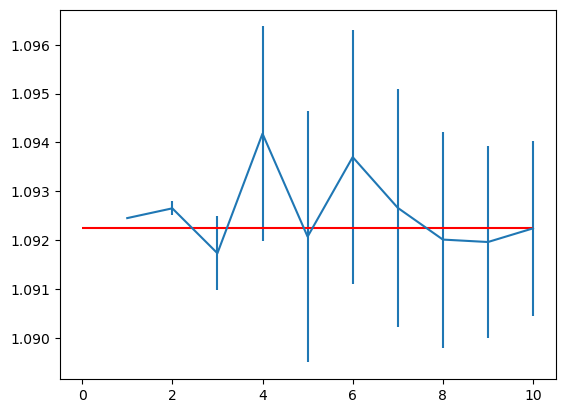

In [4]:
plt.errorbar(df1['BLOCK'],df1['T_AVE'],yerr=df1['ERROR'])
plt.hlines(df1['T_AVE'].tail(1),0,df1['BLOCK'].tail(1),color='red')
plt.show()

In [5]:
file= "/home/elisa/Scrivania/LSN/LSN/nsl_simulator/NSL_SIMULATOR/OUTPUT/potential_energy.csv"
df = pd.read_csv(file,sep ="\t")
df.head()


,BLOCK,ACTUAL_PE,PE_AVE,ERROR
0,1,-5.46073,-5.46073,0.000000
1,2,-5.46075,-5.46074,0.000008
2,3,-5.45667,-5.45938,0.001108
3,4,-5.47356,-5.46293,0.003180
4,5,-5.44684,-5.45971,0.003842


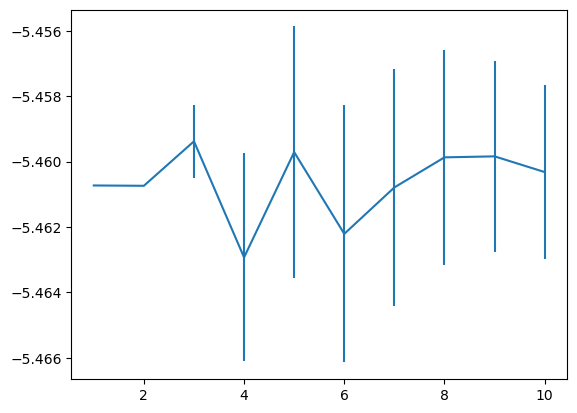

In [6]:
plt.errorbar(df['BLOCK'],df['PE_AVE'],yerr=df['ERROR'])

plt.show()

In [7]:
file= "/home/elisa/Scrivania/LSN/LSN/nsl_simulator/NSL_SIMULATOR/OUTPUT/U_block_length.csv"
df2 = pd.read_csv(file,sep ="\t")
df2


,LENGTH,ERROR
0,3500,0.002665


In [8]:
BL = df2['LENGTH'][df2['ERROR']==df2['ERROR'].min()]
BL.tolist()
print('Optimal block length: ', BL)

Optimal block length:  0    3500
Name: LENGTH, dtype: int64


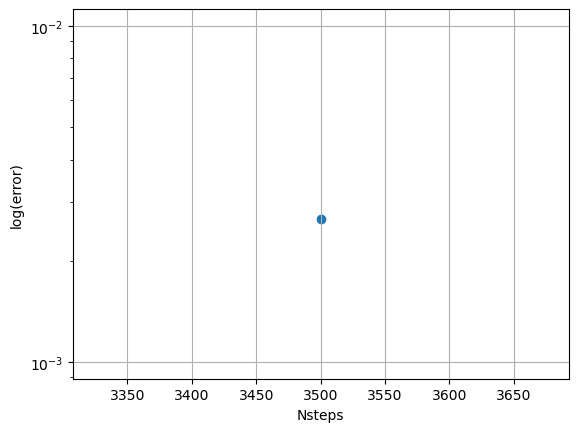

In [9]:
fig,ax = plt.subplots()
ax.scatter(df2['LENGTH'],df2['ERROR'])
ax.set_yscale('log')
plt.xlabel('Nsteps')
plt.ylabel('log(error)')
plt.grid()

In [30]:
file= "/home/elisa/Scrivania/LSN/LSN/nsl_simulator/NSL_SIMULATOR/OUTPUT/gofr.csv"
with open (file) as f:
    bin_size = f.readline()
    print(bin_size)

BIN SIZE	0.0256496



In [31]:
file= "/home/elisa/Scrivania/LSN/LSN/nsl_simulator/NSL_SIMULATOR/OUTPUT/gofr.csv"
df = pd.read_csv(file,sep ="\t", skiprows=1,skip_blank_lines = False)
df.head()

,BIN,DISTANCE,AVE_GOFR,ERROR
0,0.0,0.025650,0.0,0.0
1,1.0,0.051299,0.0,0.0
2,2.0,0.076949,0.0,0.0
3,3.0,0.102599,0.0,0.0
4,4.0,0.128248,0.0,0.0


In [32]:
T=1.1

nan_rows = df[df.isnull().all(axis=1)].index

# Add start/end points for slicing
split_points = [-1] + list(nan_rows) + [len(df)]

# Slice the DataFrame into blocks
histograms = []
for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]
    block = df.iloc[start:end].reset_index(drop=True)
    if not block.empty:
        histograms.append(block)

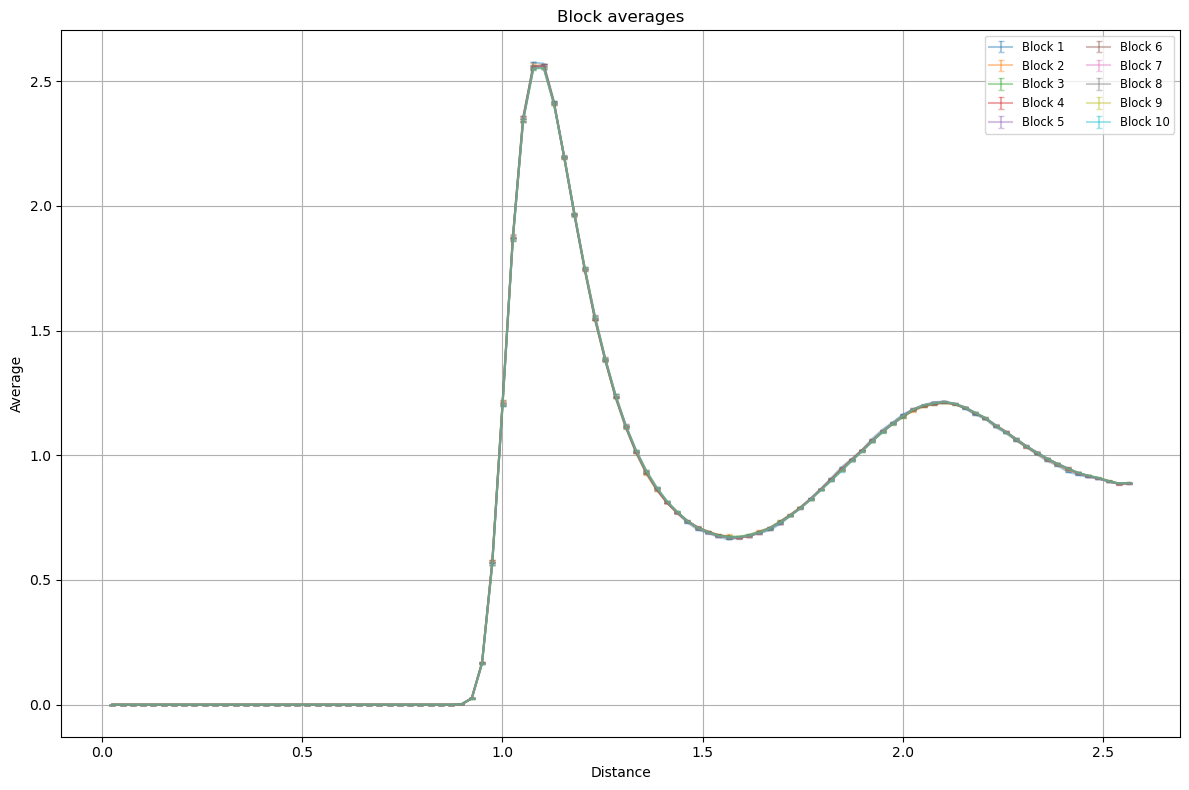

In [33]:
plt.figure(figsize=(12, 8))

for i, h in enumerate(histograms):
    plt.errorbar(
        h['DISTANCE'], h['AVE_GOFR'], yerr=h['ERROR'],
        fmt='-', capsize=2, alpha=0.4, label=f'Block {i+1}'
    )

plt.xlabel('Distance')
plt.ylabel('Average')
plt.title('Block averages')
plt.grid(True)
plt.legend(fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

In [14]:
file= "/home/elisa/Scrivania/LSN/LSN/nsl_simulator/NSL_SIMULATOR/OUTPUT/gofr_blockave.csv"
with open (file) as f:
    bin_size = f.readline()
    print(bin_size)

BIN SIZE	0.0256496



In [15]:
file= "/home/elisa/Scrivania/LSN/LSN/nsl_simulator/NSL_SIMULATOR/OUTPUT/gofr_blockave.csv"
dfa = pd.read_csv(file,sep ="\t", skiprows=1,skip_blank_lines = False)
dfa.head()

,BIN,DISTANCE,AVE_GOFR
0,0.0,0.025650,0.0
1,1.0,0.051299,0.0
2,2.0,0.076949,0.0
3,3.0,0.102599,0.0
4,4.0,0.128248,0.0


In [16]:
T=1.1

nan_rows = dfa[dfa.isnull().all(axis=1)].index

# Add start/end points for slicing
split_points = [-1] + list(nan_rows) + [len(dfa)]

# Slice the DataFrame into blocks
histograms1 = []
for i in range(len(split_points) - 1):
    start = split_points[i] + 1
    end = split_points[i + 1]
    block = dfa.iloc[start:end].reset_index(drop=True)
    if not block.empty:
        histograms1.append(block)

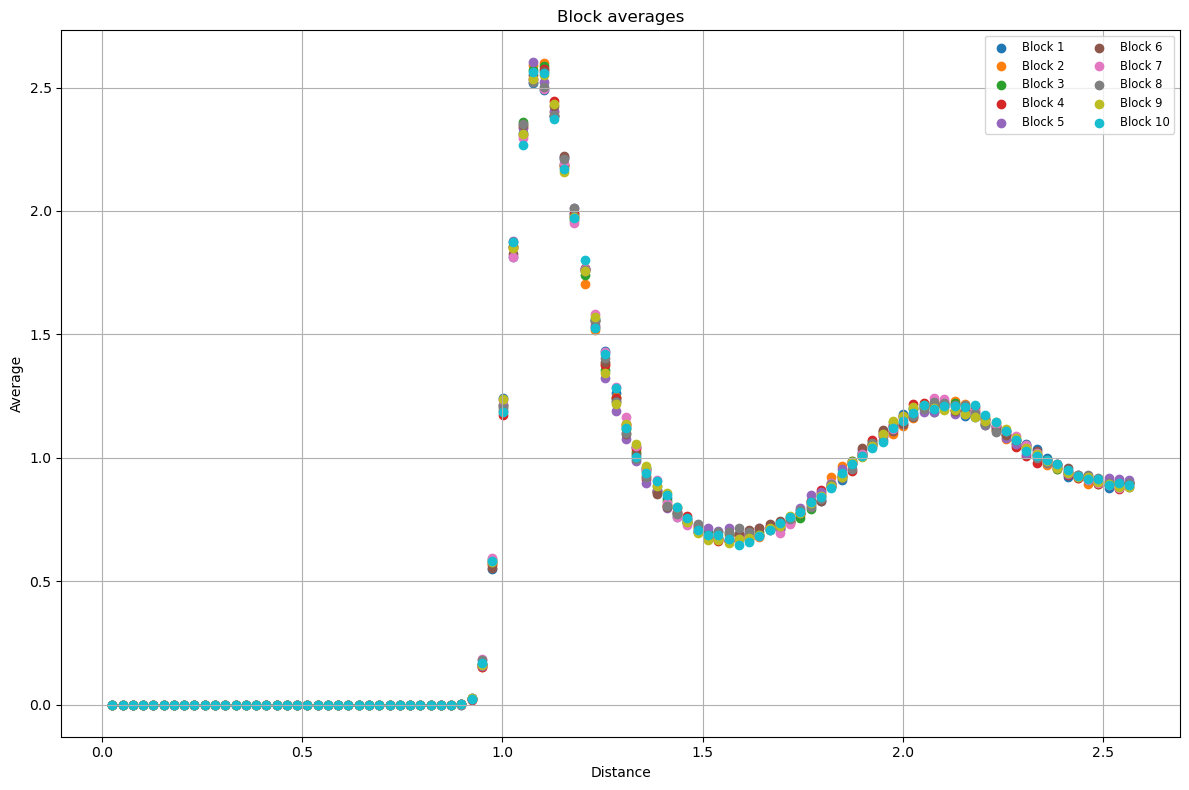

In [17]:
plt.figure(figsize=(12, 8))

for i, h in enumerate(histograms1):
    plt.scatter(
        h['DISTANCE'], h['AVE_GOFR'], label=f'Block {i+1}')

plt.xlabel('Distance')
plt.ylabel('Average')
plt.title('Block averages')
plt.grid(True)
plt.legend(fontsize='small', ncol=2)
plt.tight_layout()
plt.show()